# E-Commerce Sales Performance and Growth Sustainability Analysis

## Project Objective


The primary objective of the project is to evaluate business performance by analyzing sales trends and identifying the drivers of revenue growth.

Identify Revenue Drivers : 
Quantify the relationship between Quantity,UnitPrice and overall Revenue.

Access Growth Sustainability: 
Investigate whether rapid growth periods lead to future revenue risks using correlation analysis and performance segmetation.

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.makedirs('Picture',exist_ok='True')

# Loading dataset

In [2]:
df = pd.read_csv('clean_project_data.csv')

Add some features to the clean data set for the advanced analysis

In [3]:
df['Revenue'] = df['UnitPrice'] * df['Quantity']
df['OrderDate'] = pd.to_datetime(df['OrderDate'],errors='coerce')
df['Year_Month'] = df['OrderDate'].dt.to_period('M')
df['Year']  = df['OrderDate'].dt.year
df.head(10)

,OrderID,CustomerID,ProductCategory,ProductName,Quantity,UnitPrice,OrderDate,Region,Revenue,Year_Month,Year
0,1,2824,Electronics,Headphones,4,115.49,2020-07-28,North,461.96,2020-07,2020
1,2,7912,Electronics,Smartphone,2,113.23,2022-10-31,North,226.46,2022-10,2022
2,3,4257,Toys,Puzzle,8,296.69,2020-01-14,South,2373.52,2020-01,2020
3,4,7924,Books,Textbook,3,111.58,2021-11-20,North,334.74,2021-11,2021
4,5,2519,Toys,Action Figure,6,424.51,2023-05-21,East,2547.06,2023-05,2023
5,6,1711,Grocery,Bread,2,486.69,2022-02-14,North,973.38,2022-02,2022
6,7,5803,Books,Magazine,4,353.76,2020-04-03,South,1415.04,2020-04,2020
7,8,5741,Clothing,Jeans,2,193.16,2022-07-17,East,386.32,2022-07,2022
8,9,3664,Books,Textbook,4,336.74,2023-12-08,North,1346.96,2023-12,2023
9,10,3803,Beauty,Foundation,8,192.83,2023-08-03,South,1542.64,2023-08,2023


## Exploratory Data Analysis

In [4]:
df.columns

Index(['OrderID', 'CustomerID', 'ProductCategory', 'ProductName', 'Quantity',
       'UnitPrice', 'OrderDate', 'Region', 'Revenue', 'Year_Month', 'Year'],
      dtype='object')

Check the number of category in the dataset

In [5]:
no_of_category = df['ProductCategory'].nunique()
no_of_category

8

In [6]:

def performance(x):
    if x > 220000 :
        return 'High'
    elif x > 200000 : 
        return 'Medium'
    else :
        return 'Low'

Analyzing the category revenue and ranking by its revenue for finding the top category.

In [7]:
# Category Analysis
category_revenue = df.groupby('ProductCategory')['Revenue'].sum().reset_index()
category_revenue = category_revenue.sort_values(by='Revenue',ascending=False).groupby('ProductCategory').head()
category_revenue

,ProductCategory,Revenue
1,Books,256203.26
7,Toys,224094.91
6,Sports,207171.77
3,Electronics,204164.07
0,Beauty,191888.00
2,Clothing,191431.52
4,Grocery,190332.43
5,Home,189646.64


In [8]:
category_revenue['Rank'] = category_revenue['Revenue'].rank(method='first',ascending=False)
category_revenue['Performance'] = category_revenue['Revenue'].apply(performance)
category_revenue

,ProductCategory,Revenue,Rank,Performance
1,Books,256203.26,1.0,High
7,Toys,224094.91,2.0,High
6,Sports,207171.77,3.0,Medium
3,Electronics,204164.07,4.0,Medium
0,Beauty,191888.00,5.0,Low
2,Clothing,191431.52,6.0,Low
4,Grocery,190332.43,7.0,Low
5,Home,189646.64,8.0,Low


In [9]:
top_3_category = category_revenue[category_revenue['Rank'] <= 3]
top_3_category

,ProductCategory,Revenue,Rank,Performance
1,Books,256203.26,1.0,High
7,Toys,224094.91,2.0,High
6,Sports,207171.77,3.0,Medium


## Set the background color and style

In [10]:
sns.set_palette('pastel')
sns.set_style('darkgrid')

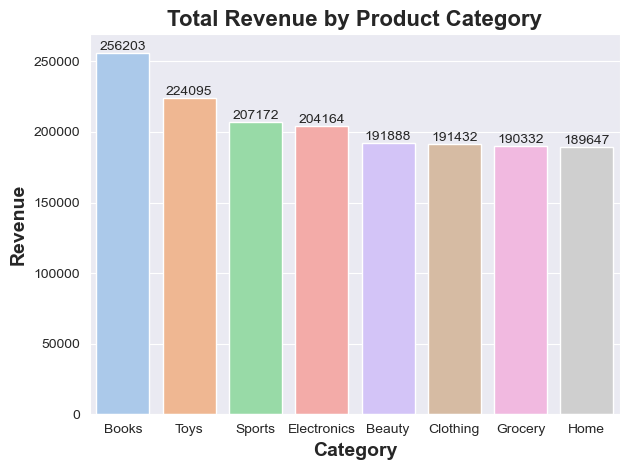

In [11]:
sns.barplot(data=category_revenue, x='ProductCategory', y='Revenue',estimator=sum)
plt.title("Total Revenue by Product Category",fontweight='bold',fontsize=16)
plt.xlabel('Category',fontweight='bold',fontsize=14)
# Show revenue values for each product
plt.gca().bar_label(plt.gca().containers[0])
plt.ylabel('Revenue',fontweight='bold',fontsize=14)
plt.tight_layout()
plt.savefig("Picture/Total_revenue_by_product_category.jpg",dpi=300)
plt.show()

Books lead as the highest revenue‑generating category, outperforming all others. While Toys, Sports, Electronics, Beauty, Clothing, Grocery, and Home contribute significantly, highlighting Books as the clear top performer and a key driver of overall sales.

## Regional Revenue Trend 

In [12]:
regional_revenue = df.groupby('Region')['Revenue'].sum().reset_index()
regional_revenue

,Region,Revenue
0,East,456475.93
1,North,410341.64
2,South,372990.80
3,West,415124.23


In [13]:
regional_revenue = regional_revenue.sort_values(by='Revenue',ascending=False).groupby('Region').head()
regional_revenue['Rank'] = regional_revenue['Revenue'].rank(method='dense',ascending=False)
regional_revenue

,Region,Revenue,Rank
0,East,456475.93,1.0
3,West,415124.23,2.0
1,North,410341.64,3.0
2,South,372990.80,4.0


In [14]:
top_region = regional_revenue[regional_revenue['Rank'] == 1]
top_region

,Region,Revenue,Rank
0,East,456475.93,1.0


In [15]:
regional_revenue['Revenue']

0    456475.93
3    415124.23
1    410341.64
2    372990.80
Name: Revenue, dtype: float64

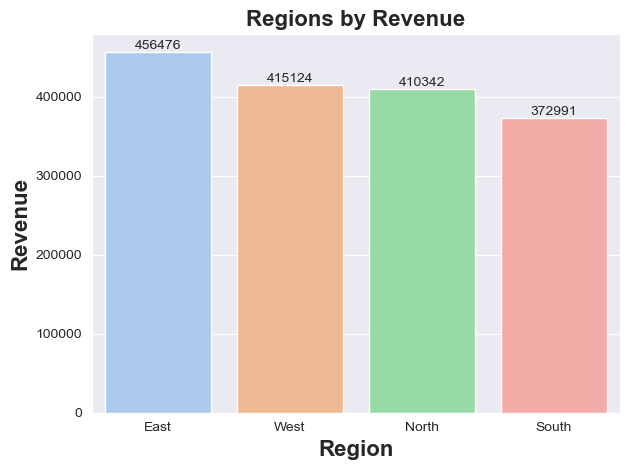

In [16]:
sns.barplot(data=regional_revenue,x='Region',y='Revenue')
plt.title('Regions by Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Region',fontsize=16,fontweight='bold')
# Show value with region
plt.gca().bar_label(plt.gca().containers[0])
plt.ylabel('Revenue',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('Picture/Regions_by_Revenue.jpg',dpi=300)
plt.show()

The East region leads with the highest revenue, followed closely by West and North, while the South region lags behind. This highlights strong performance in the East and opportunities to strengthen sales strategies in the South to balance regional contributions.

## Product Quantity Trend & Product Revenue Analysis

In [17]:
#first check the number of product and quantity sold
no_of_product = df['ProductName'].nunique()
no_of_quantitysold = df['Quantity'].sum()
no_of_product

40

In [18]:
no_of_quantitysold

6657

In [19]:
# Analyze the items sold with product
quantity_sold_product = df.groupby('ProductName')['Quantity'].sum().reset_index()
quantity_sold_product

,ProductName,Quantity
0,Action Figure,115
1,Bicycle,144
2,Biography,168
3,Board Game,174
4,Bread,191
5,Camera,222
6,Chair,136
7,Comics,221
8,Curtains,172
9,Doll,231


In [20]:
product_revenue = df.groupby('ProductName')['Revenue'].sum().reset_index()
product_revenue = product_revenue.sort_values(by='Revenue',ascending=False).groupby('ProductName').head()
product_revenue

,ProductName,Revenue
9,Doll,64230.19
7,Comics,59208.01
25,Novel,57142.87
29,Rice,57027.18
38,Textbook,55437.36
30,Shampoo,55400.51
33,Sofa,54178.70
5,Camera,52516.44
28,Puzzle,47312.43
27,Perfume,46976.22


In [21]:
product_revenue['Rank'] = product_revenue['Revenue'].rank(method='dense',ascending=False)


In [22]:
top_10_products = product_revenue[product_revenue['Rank']< 11]
top_10_products

,ProductName,Revenue,Rank
9,Doll,64230.19,1.0
7,Comics,59208.01,2.0
25,Novel,57142.87,3.0
29,Rice,57027.18,4.0
38,Textbook,55437.36,5.0
30,Shampoo,55400.51,6.0
33,Sofa,54178.70,7.0
5,Camera,52516.44,8.0
28,Puzzle,47312.43,9.0
27,Perfume,46976.22,10.0


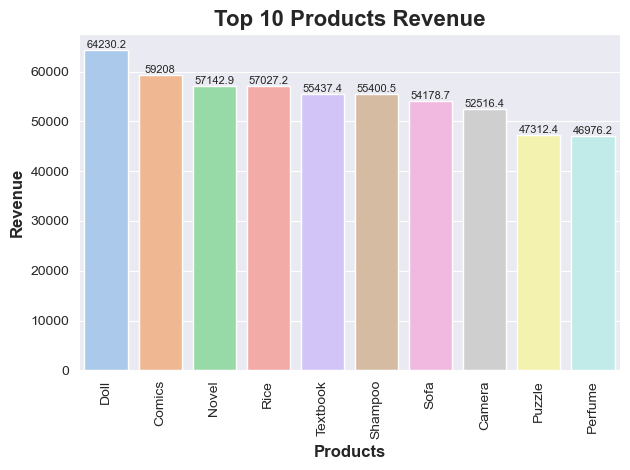

In [23]:
sns.barplot(data=top_10_products,x='ProductName',y='Revenue')
plt.title('Top 10 Products Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Products',fontsize=12,fontweight='bold')
plt.ylabel('Revenue',fontsize=12,fontweight='bold')
plt.gca().bar_label(plt.gca().containers[0],fontsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Picture/Top_10_Products_Revenue.jpg',dpi=300)
plt.show()

Among the top 10 products, Doll generates the highest revenue, while Perfume records the lowest. The spread between products highlights clear leaders and laggards, suggesting opportunities to strengthen sales strategies for lower‑performing items while capitalizing on the strong demand for top earners.

# Time Trends

In [24]:
yearly_month_revenue = df.groupby('Year_Month')['Revenue'].sum().reset_index()
yearly_month_revenue = yearly_month_revenue.sort_values(by='Revenue',ascending=False).groupby('Year_Month').head()
yearly_month_revenue.head(5)

,Year_Month,Revenue
3,2020-04,52903.51
42,2023-07,51006.23
46,2023-11,48771.06
11,2020-12,48400.28
41,2023-06,46180.41


In [25]:
yearly_month_revenue['Rank'] = yearly_month_revenue['Revenue'].rank(method='dense',ascending=False)
yearly_month_revenue

,Year_Month,Revenue,Rank
3,2020-04,52903.51,1.0
42,2023-07,51006.23,2.0
46,2023-11,48771.06,3.0
11,2020-12,48400.28,4.0
41,2023-06,46180.41,5.0
40,2023-05,46126.65,6.0
7,2020-08,45432.27,7.0
28,2022-05,45197.17,8.0
18,2021-07,44934.00,9.0
2,2020-03,44068.50,10.0


In [26]:
top_10_yearly_month_revenue = yearly_month_revenue[yearly_month_revenue['Rank']<11]
top_10_yearly_month_revenue

,Year_Month,Revenue,Rank
3,2020-04,52903.51,1.0
42,2023-07,51006.23,2.0
46,2023-11,48771.06,3.0
11,2020-12,48400.28,4.0
41,2023-06,46180.41,5.0
40,2023-05,46126.65,6.0
7,2020-08,45432.27,7.0
28,2022-05,45197.17,8.0
18,2021-07,44934.00,9.0
2,2020-03,44068.50,10.0


In [27]:
yearly_month_revenue.dtypes

Year_Month    period[M]
Revenue         float64
Rank            float64
dtype: object

In [28]:
yearly_month_revenue['Year_Month'] = yearly_month_revenue['Year_Month'].astype(str)
yearly_month_revenue.dtypes

Year_Month     object
Revenue       float64
Rank          float64
dtype: object

In [29]:
top_10_yearly_month_revenue['Year_Month'] = top_10_yearly_month_revenue['Year_Month'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_15404\3691512149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_yearly_month_revenue['Year_Month'] = top_10_yearly_month_revenue['Year_Month'].astype(str)


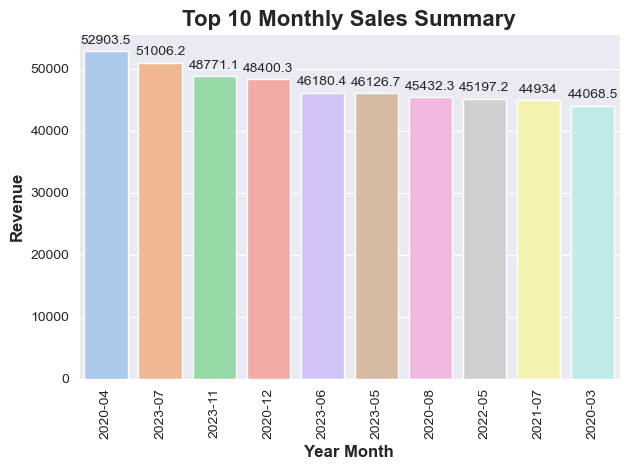

In [55]:
sns.barplot(data=top_10_yearly_month_revenue,x='Year_Month',y='Revenue')
plt.title('Top 10 Monthly Sales Summary',fontweight='bold',fontsize=16)
plt.gca().bar_label(plt.gca().containers[0],fontsize=10,padding=3)
plt.xlabel('Year Month',fontweight='bold',fontsize=12)
plt.ylabel('Revenue',fontweight='bold',fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Picture/MOnthly_Sales_Summary.jpg',dpi=300)
plt.show()


In [31]:
yearly_revenue = df.groupby('Year')['Revenue'].sum().reset_index()
yearly_revenue = yearly_revenue.sort_values(by='Revenue',ascending=False).groupby('Year').head()

In [32]:
yearly_revenue

,Year,Revenue
3,2023,460271.83
0,2020,459259.12
1,2021,391354.15
2,2022,344047.50


In [33]:

yearly_revenue['Rank'] = yearly_revenue['Revenue'].rank(method='first',ascending=False)
yearly_revenue

,Year,Revenue,Rank
3,2023,460271.83,1.0
0,2020,459259.12,2.0
1,2021,391354.15,3.0
2,2022,344047.50,4.0


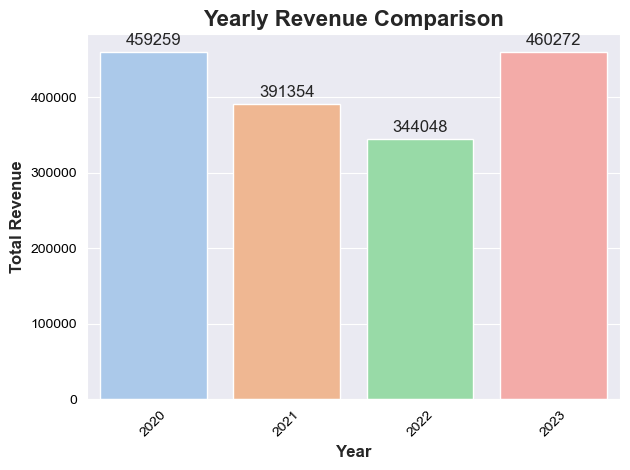

In [34]:
sns.barplot(data=yearly_revenue,x='Year',y='Revenue')
plt.title('Yearly Revenue Comparison',fontsize=16,fontweight='bold')
plt.gca().bar_label(plt.gca().containers[0],fontsize=12,padding=3)
plt.xlabel('Year',fontsize=12,fontweight='bold')
plt.ylabel('Total Revenue',fontsize=12,fontweight='bold')

plt.tick_params(axis='x',labelsize=10,labelcolor='black',rotation=45)
plt.tick_params(axis='y',labelsize=10,labelcolor='black',rotation=0)
plt.tight_layout()
plt.savefig('Picture/Yearly_Revenue_Comaprison.jpg',dpi=300)
plt.show()


Revenue performance fluctuated across the four years, with 2023 achieving the highest revenue, surpassing all previous years. In contrast, 2022 recorded the lowest revenue, signaling a dip before recovery. This trend highlights both volatility and growth potential, with 2023 marking a strong rebound and peak performance.

## Customers Behavior

In [35]:
customer_spent = df.groupby('CustomerID')['Revenue'].sum().reset_index()
customer_spent = customer_spent.sort_values(by='Revenue',ascending=False).groupby('CustomerID').head()
customer_spent

,CustomerID,Revenue
1008,9037,6995.92
621,6038,6183.20
779,7397,6151.01
945,8581,5862.47
1018,9138,5552.20
...,...,...
914,8414,24.36
731,6971,22.17
1120,9972,21.84
1075,9541,18.81


In [36]:
customer_spent = customer_spent.sort_values(by='Revenue',ascending=False).groupby('CustomerID').head()

In [37]:
customer_spent['Rank'] = customer_spent['Revenue'].rank(method='dense',ascending=False)
customer_spent

,CustomerID,Revenue,Rank
1008,9037,6995.92,1.0
621,6038,6183.20,2.0
779,7397,6151.01,3.0
945,8581,5862.47,4.0
1018,9138,5552.20,5.0
...,...,...,...
914,8414,24.36,1117.0
731,6971,22.17,1118.0
1120,9972,21.84,1119.0
1075,9541,18.81,1120.0


In [38]:
top_10_customers = customer_spent[customer_spent['Rank']<11]
top_10_customers.dtypes

CustomerID      int64
Revenue       float64
Rank          float64
dtype: object

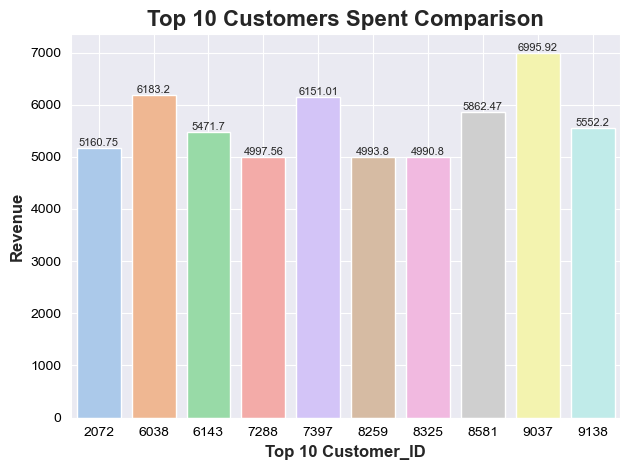

In [39]:

sns.barplot(data=top_10_customers,x='CustomerID',y='Revenue')
plt.title('Top 10 Customers Spent Comparison',fontsize=16,fontweight='bold')
plt.xlabel('Top 10 Customer_ID',fontsize=12,fontweight='bold')
plt.ylabel('Revenue',fontsize=12,fontweight='bold')
plt.gca().bar_label(plt.gca().containers[0],fontsize=8)
plt.tick_params(axis='x',labelsize=10,labelcolor='black',rotation=0)
plt.tick_params(axis='y',labelsize=10,labelcolor='black',rotation=0)
plt.tight_layout()
plt.grid(True)
plt.savefig('Picture/Top_10_Customers_Spent_Comparison.jpg',dpi=300)
plt.show()

Customer 9037 stands out as the highest revenue contributor among the top 10, while customers 7288, 8259, and 8325 generate comparatively lower revenues. This highlights the importance of focusing retention and engagement strategies on high‑value clients, while exploring growth opportunities with mid‑tier customers.

## Relationship between Quantity and Price

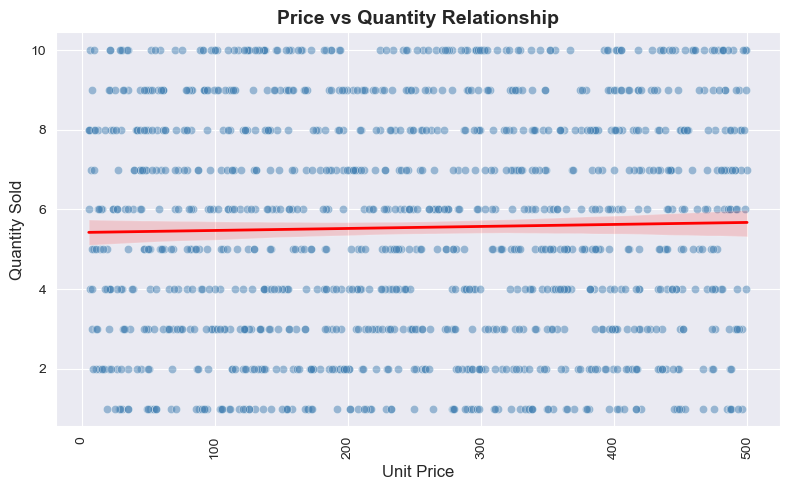

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='UnitPrice', y='Quantity', alpha=0.5, color='steelblue')
# Add regression line
sns.regplot(data=df, x='UnitPrice', y='Quantity',
            scatter=False, color='red', line_kws={'linewidth':2})
plt.title('Price vs Quantity Relationship', fontsize=16, fontweight='bold')
plt.xlabel('Unit Price', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.savefig('Picture/Price_vs_Quantity_Relationship.jpg',dpi=300)
plt.show()


There is a weak positive relationship between Unit Price and Quantity Sold.This suggests that higher-priced items in the dataset are not reducing demand; instead, they may be linked to slightly higher quantities purchased. This pattern points to possible customer preference for premium products or bulk buying behavior.

## Unit Price Distribution and Revenue Distribution are shown within the subplots

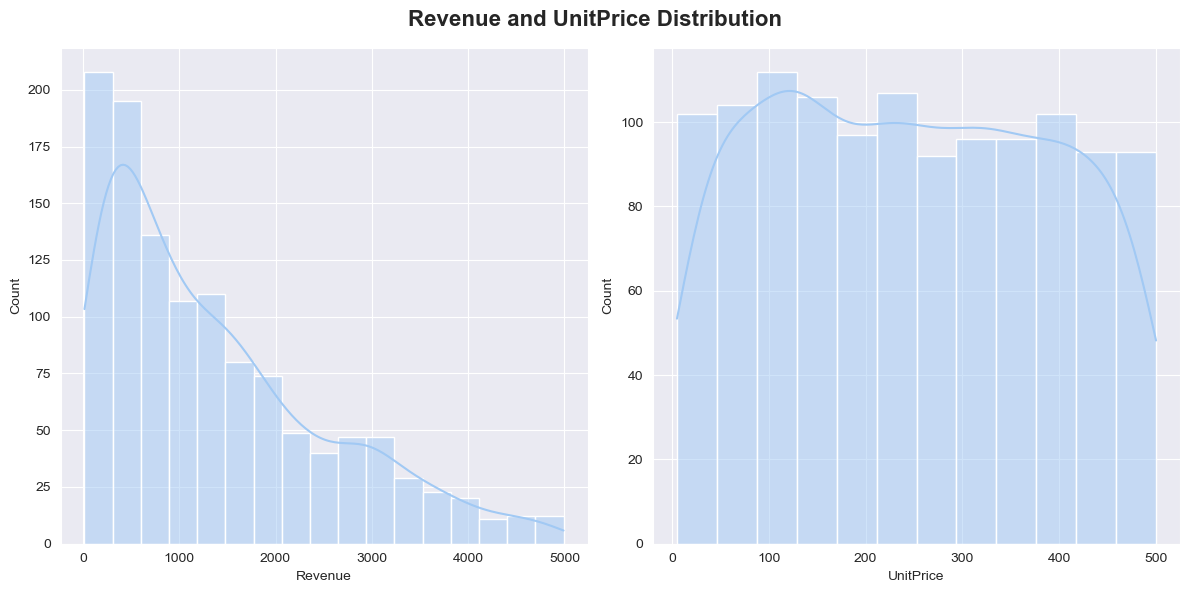

In [41]:
fig , ax = plt.subplots(1,2,figsize=(12,6))
fig.suptitle('Revenue and UnitPrice Distribution',fontsize=16,fontweight='bold')
sns.histplot(data=df,x='Revenue',kde=True, ax=ax[0])
sns.histplot(data= df,x='UnitPrice',kde=True, ax=ax[1])
plt.tight_layout()
plt.savefig('Picture/Revenue_and_UnitPrice_Distribution.jpg',dpi=300,bbox_inches='tight')
plt.grid(True)
plt.show()

Most transcations generate relatively low revenue, while a small number of orders contributes significantly higher revenue. This inidicates a right-skewed distribution, where the business relies on a few high-value transcations.

The unit price distribution appears relatively uniform across the range, suggesting that products are offered at a wide variety of price points without a strong concentration in a specific range.

## Outliers Detection 

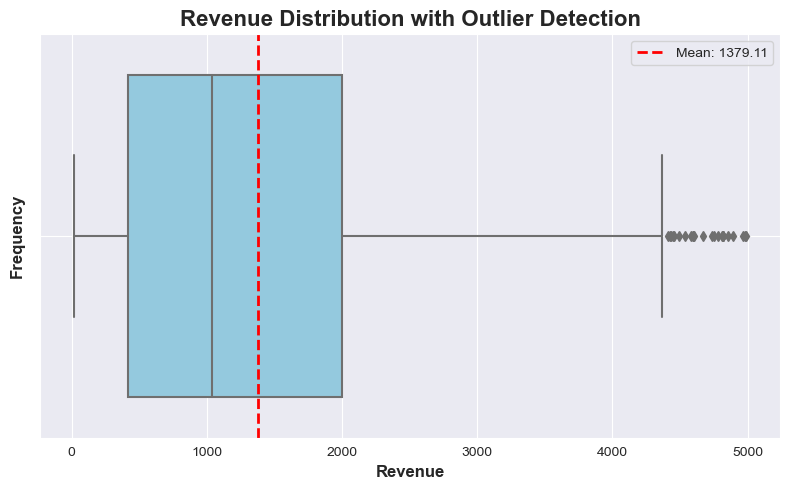

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Revenue', color='skyblue')

# Calculate mean
mean_value = df['Revenue'].mean()

# Add mean line
plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')

# Add title and axis labels
plt.title('Revenue Distribution with Outlier Detection', fontsize=16, fontweight='bold')
plt.xlabel('Revenue', fontsize=12,fontweight='bold')
plt.ylabel('Frequency', fontsize=12,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.savefig('Picture/Revenue_Distribution_with_Outlier_Detection.jpg',dpi=300,bbox_inches='tight')
plt.show()


The distribution reveals that most revenue values cluster between 0 and 2000, with a median around 1000, meaning the majority of transactions generate relatively modest revenue. However, the whiskers extend up to 4000 and there are clear outliers between 4000 and 5000, showing that while rare, exceptionally high revenue events do occur.

In [43]:
df.columns

Index(['OrderID', 'CustomerID', 'ProductCategory', 'ProductName', 'Quantity',
       'UnitPrice', 'OrderDate', 'Region', 'Revenue', 'Year_Month', 'Year'],
      dtype='object')

In [44]:
# Advanced window analysis

In [45]:
df = df.sort_values(by=['ProductName','OrderDate'])
df['Running_Total'] = df['Revenue'].cumsum()
df['Prev'] = df['Revenue'].shift(1)
df['Next_Revenue'] = df['Revenue'].shift(-1)
df['Growth'] = df['Revenue'] - df['Prev']
df

,OrderID,CustomerID,ProductCategory,ProductName,Quantity,UnitPrice,OrderDate,Region,Revenue,Year_Month,Year,Running_Total,Prev,Next_Revenue,Growth
1107,1108,2007,Toys,Action Figure,3,451.74,2020-04-28,East,1355.22,2020-04,2020,1355.22,NaN,1049.20,NaN
356,357,6315,Toys,Action Figure,5,209.84,2020-06-22,South,1049.20,2020-06,2020,2404.42,1355.22,2170.95,-306.02
397,398,3221,Toys,Action Figure,5,434.19,2020-09-16,South,2170.95,2020-09,2020,4575.37,1049.20,442.71,1121.75
1089,1090,8345,Toys,Action Figure,3,147.57,2021-01-28,West,442.71,2021-01,2021,5018.08,2170.95,53.81,-1728.24
370,371,6432,Toys,Action Figure,1,53.81,2021-03-30,South,53.81,2021-03,2021,5071.89,442.71,207.68,-388.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,236,9937,Sports,Yoga Mat,2,44.63,2023-09-15,East,89.26,2023-09,2023,1650790.63,2040.32,1284.64,-1951.06
1103,1104,2396,Sports,Yoga Mat,7,183.52,2023-09-23,South,1284.64,2023-09,2023,1652075.27,89.26,1431.52,1195.38
821,822,6826,Sports,Yoga Mat,4,357.88,2023-10-05,North,1431.52,2023-10,2023,1653506.79,1284.64,353.76,146.88
553,554,2037,Sports,Yoga Mat,1,353.76,2023-10-20,South,353.76,2023-10,2023,1653860.55,1431.52,1072.05,-1077.76


In [46]:
# Growth Summary of Product
growth_summary = df.groupby('ProductName')['Growth'].mean().reset_index()
growth_summary 
growth_summary = growth_summary.sort_values(by='Growth',ascending=False).groupby('ProductName').head()
growth_summary['Rank'] = growth_summary['Growth'].rank(method='dense',ascending=False)
growth_summary
top_3_fastest_growth_summary = growth_summary[growth_summary['Rank']<4]
top_3_fastest_growth_summary

,ProductName,Growth,Rank
10,Dress,136.384667,1.0
1,Bicycle,119.540000,2.0
18,Lamp,89.642917,3.0


 Change the Product's Growth with absolute() function for analyzing the stable product

In [47]:
growth_summary['Abs_Growth'] = growth_summary['Growth'].abs()
growth_summary

,ProductName,Growth,Rank,Abs_Growth
10,Dress,136.384667,1.0,136.384667
1,Bicycle,119.540000,2.0,119.540000
18,Lamp,89.642917,3.0,89.642917
3,Board Game,71.806667,4.0,71.806667
16,Jacket,67.619333,5.0,67.619333
29,Rice,47.096585,6.0,47.096585
38,Textbook,41.085625,7.0,41.085625
27,Perfume,37.232581,8.0,37.232581
5,Camera,35.211220,9.0,35.211220
25,Novel,22.263500,10.0,22.263500


In [48]:
top_3_stable_product = growth_summary.sort_values(by='Abs_Growth').head(3)
top_3_stable_product

,ProductName,Growth,Rank,Abs_Growth
0,Action Figure,1.017391,21.0,1.017391
20,Lego Set,1.583704,20.0,1.583704
34,Sweater,1.984615,19.0,1.984615


Analyzing the most volatile products from the dataset

In [49]:
volatility = df.groupby('ProductName')['Growth'].std().reset_index()
volatility.rename(columns={'Growth':'Volatile'},inplace=True)
most_volatile = volatility.sort_values(by='Volatile',ascending=False).head(1)
most_volatile

,ProductName,Volatile
28,Puzzle,2258.034922


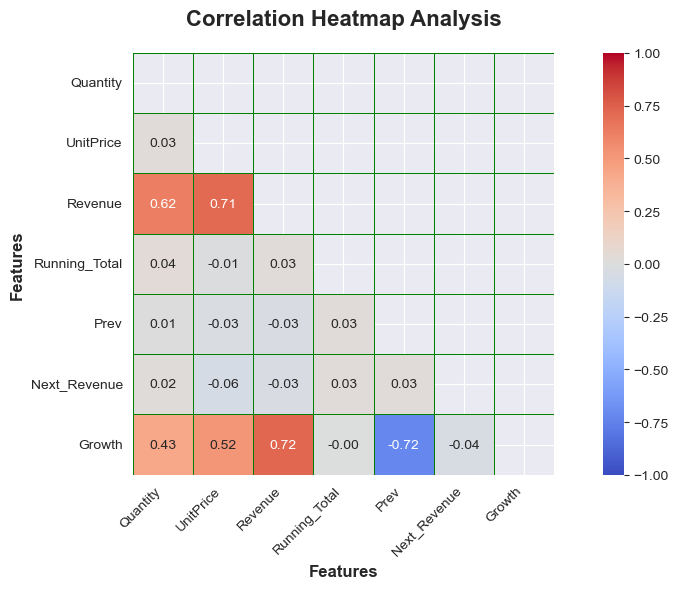

In [58]:
# Correlation Analysis 
mask = np.triu(np.ones_like(df[['Quantity','UnitPrice','Revenue','Running_Total','Prev','Next_Revenue','Growth']].corr(),dtype=bool))
corr = df[['Quantity','UnitPrice','Revenue','Running_Total','Prev','Next_Revenue','Growth']].corr()
plt.figure(figsize=(10,6))
plt.title('Correlation Heatmap Analysis',fontsize = 16,pad=20,fontweight='bold')
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt= '.2f',
            linecolor='Green',
            square = True,
            mask = mask,
            vmin=-1,
            vmax=1,
            center=0,
            linewidths=0.5)
plt.xlabel('Features',fontsize=12,fontweight='bold')
plt.ylabel('Features',fontsize=12,fontweight='bold')
plt.xticks(rotation= 45,ha='right')
plt.tight_layout()
plt.grid(True)
plt.savefig('Picture/Correlation_Heatmap_Analysis.jpg',bbox_inches='tight',dpi=300)
plt.show()

Revenue is the central driver of business performance, tightly linked to both Quantity and UnitPrice, and directly influencing Growth. 
The strong positive correlations (Revenue–Quantity: 0.71, Revenue–UnitPrice: 0.62, Revenue–Growth: 0.72) highlight that increasing either sales volume or pricing strategy has a measurable impact on overall growth.
    
However, the negative correlation between Growth and Next_Revenue (-0.72) signals a potential risk: periods of rapid growth may be followed by revenue declines. 
This suggests that growth spikes could be unsustainable, possibly due to short-term promotions, seasonal demand, or customer churn after peak activity.

## Executive Summary

This analysis provides a comprehensive look at how sales volume and pricing strategies impact long-term business health.Key findings include:
- Data Integrity :
    Successfully handled missing values using a localized groupby imputation strategy,ensuring that product-specific pricing and quantites remained accurate.
- Key Performance Indicators :
    Developed a performance scoring system by products to categorize revenue streams into High,Medium and Low segments.
    - Calculated Growth metrics and Next-Month Revenue to predict business stability.
- Critical Insights 
    - Direct Drivers: Revenue is strongly driven by Quantity(0.71 correlation) and UnitPrice(0.62),suggesting a balanced approach to volume and pricing is essential.
- Sustianability Warning:
    - A strong negative correlation (-0.71) between current Growth and future Revenue was identified. This indictes that sudden growth spikes might be unsustainable,potentially due to seasonal fluctuations or short-term promotions don't convert into long-term customer retention.